#### Exercise 3 - Kraftwerkseinsatzplanung

VU - Energiemodelle und Analysen

Gruppe 10 - Hannah Bennoui, Peter Geyrhofer, Johannes Tanzer, Clemens Stadler

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import gurobipy as gp
from gurobipy import GRB

### Parameter und Vorbereitung

In [2]:
# Import der .csv Datei und Umwandelung in pandas-dataframe

df_load = pd.read_csv('Last_PV_Wind.csv', sep=';')

In [3]:
# Parameterdefinition

power_coal = 600 #MW
power_gud = 400 #MW
power_gas = 300 #MW
power_pumps = 200 #MW
power_PV_inst = 100 #MW
power_wind_inst = 300 #MW
power_wind = df_load['Wind 300 MW'].values
power_PV = df_load['PV 100 MW Winter'].values
eta_coal = 0.41
eta_gud = 0.58
eta_gas = 0.4
eta_turbine = 0.9
eta_pump = 0.9
fuelcost_coal = 10 #€/MWh
fuelcost_gas = 45 #€/MWh
CO2_coal = 0.35 #%
CO2_ngas = 0.2 #%
CO2_price = 80 #€/t
capacity_pumps = 600 #MWh
H_coal = 8 # MWh/t
H_ngas = 14 # MWh/t
T = 24

In [4]:
# Berechnung der Marginal Costs

mc_coal = fuelcost_coal/(eta_coal*H_coal)+(CO2_price*CO2_coal)/eta_coal
mc_gud = fuelcost_gas/(eta_gud*H_ngas)+(CO2_price*CO2_ngas)/eta_gud
mc_gas = fuelcost_gas/(eta_gas*H_ngas)+(CO2_price*CO2_ngas)/eta_gas
mc_pumps = 0
mc_PV = 0
mc_Wind = 0

print(round(mc_gas,2),round(mc_gud,2),round(mc_coal,2))

48.04 33.13 71.34


In [5]:
CO2_coal = CO2_coal/eta_coal
CO2_gas = CO2_ngas/eta_gas
CO2_gud = CO2_ngas/eta_gud

### Task 1 - Fossile Erzeugung

#### a) Kraftwerkseinsatzoptimierung

In [6]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["GuD", "Gasturbine", "Kohle"]
n_units = 3  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [CO2_gud, CO2_gas, CO2_coal]
mc = [[mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit
p_max = [power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        p[i, t] = model.addVar(lb=0, ub=p_max[i], name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")
        # Strompreis (Schattenpreis)
        constr = model.getConstrByName(f"load_{t}")
        if constr is not None:
            strompreis = constr.Pi
            print(f"  Strompreis: {strompreis:.2f} €/MWh")
            strompreis_liste.append({
                "Stunde": t,
                "Strompreis [€/MWh]": strompreis
            })

Restricted license - for non-production use only - expires 2026-11-23


Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 24 rows, 72 columns and 72 nonzeros
Model fingerprint: 0xea8612df
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+01]
  Bounds range     [3e+02, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 19 rows and 57 columns
Presolve time: 0.01s
Presolved: 5 rows, 15 columns, 15 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.1473348e+06   1.525000e+02   0.000000e+00      0s
       5    1.1655221e+06   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.165522065e+06
Stunde 0:
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 20.00 MW
  Strompreis: 71.34 €/MWh
Stunde 1:
  GuD: 400.00

In [7]:
# Speichern der Ergebnisse in dataframe und Berechnung der Kosten und CO2-Emission pro Stunde

ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X  # MW
        kosten = mc[i][t] * leistung
        emission = co2_faktoren[i] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission,
        })
df_res = pd.DataFrame(ergebnisse)

In [8]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_res["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 1165522.07 €
Gesamtemissionen: 12933.76 Tonnen CO2


#### b) Grafische Darstellung der Situation

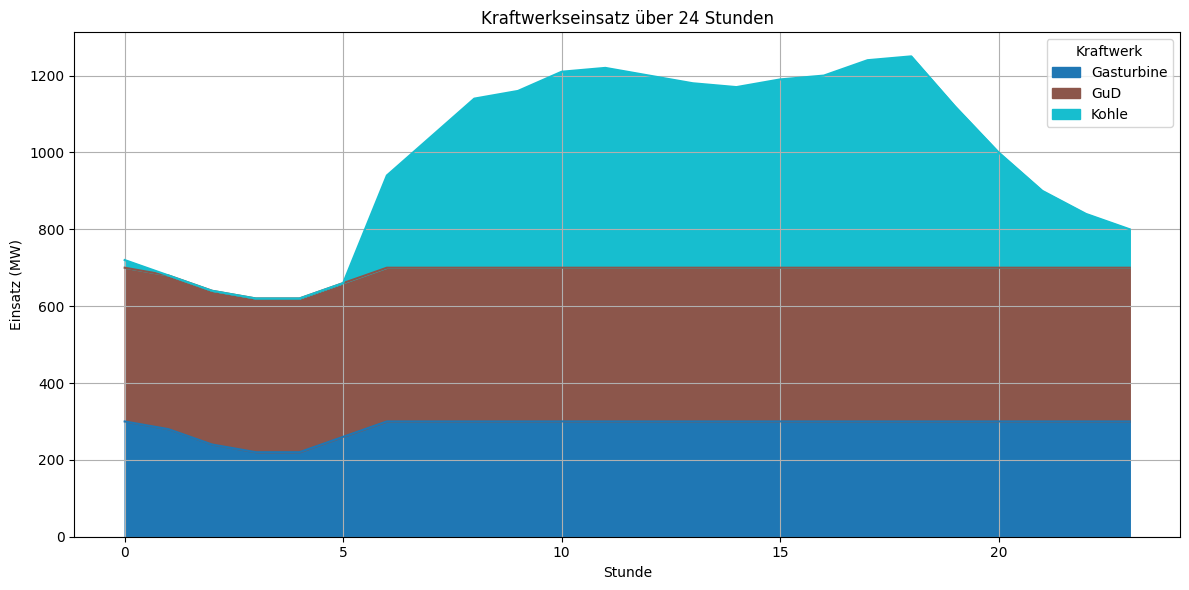

In [9]:
# Grafische Darstellung des Kraftwerkseinsatzes

df_utilization = df_res.pivot(index="Stunde", columns="Kraftwerk", values="Einsatz (MW)")

# Plot
df_utilization.plot.area(figsize=(12, 6), cmap="tab10")
plt.title("Kraftwerkseinsatz über 24 Stunden")
plt.xlabel("Stunde")
plt.ylabel("Einsatz (MW)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

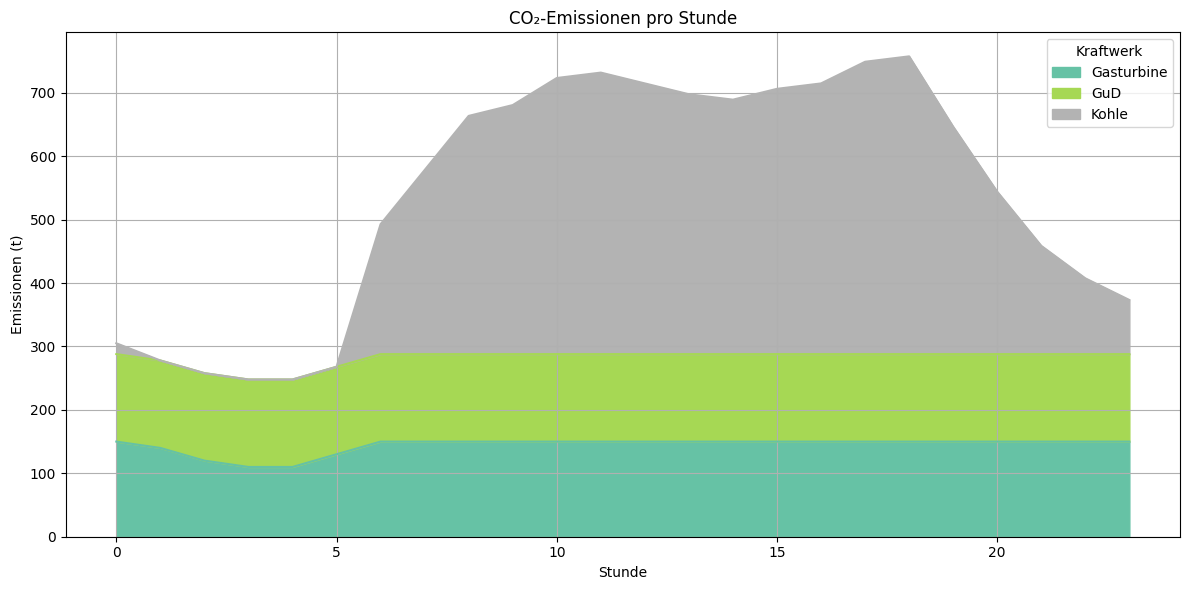

In [10]:
# Grafische Darstellung der CO2-Emissionen pro Stunde

df_emission = df_res.pivot(index="Stunde", columns="Kraftwerk", values="CO2 (t)")
df_emission.plot.area(figsize=(12, 6), cmap="Set2")
plt.title("CO₂-Emissionen pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Emissionen (t)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

#### c) Interpretation der Schattenvariable

#### d) Strompreis pro Stunde

In [11]:
df_shadow = pd.DataFrame(strompreis_liste)

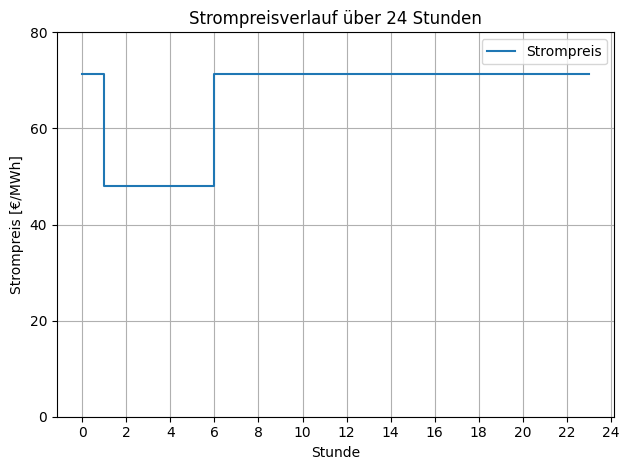

In [12]:
# Grafische Darstellung der Schattenvariable
plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

### Task 2 - Erneuerbare Erzeugung

#### a) Kraftwerkseinsatzoptimierung

In [13]:
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
n_units = 5  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]
mc = [[mc_Wind]*T,[mc_PV]*T, [mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit (z.B. 100 MW)
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
        if i == 0:
            ub = power_wind[t]  # Wind
        elif i == 1:
            ub = power_PV[t]    # PV
        else:
            ub = p_max[i]       # Konstante für konventionelle Kraftwerke
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")
        # Strompreis (Schattenpreis)
        constr = model.getConstrByName(f"load_{t}")
        if constr is not None:
            strompreis = constr.Pi
            print(f"  Strompreis: {strompreis:.2f} €/MWh")
            strompreis_liste.append({
                "Stunde": t,
                "Strompreis [€/MWh]": strompreis
            })

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0xe0160ec2
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 7e+01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 16 rows and 88 columns
Presolve time: 0.01s
Presolved: 8 rows, 32 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.0350760e+05   5.667500e+02   0.000000e+00      0s
       8    9.7359709e+05   0.000000e+00   0.000000e+00      0s

Solved in 8 iterations and 0.01 seconds (0.00 work units)
Optimal objective  9.735970915e+05
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 160.00 MW
  Kohle: 0.00 MW
  Strompreis: 48

In [14]:
# Speichern der Ergebnisse in dataframe und Berechnung der Kosten und CO2-Emission pro Stunde

ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X  # MW
        kosten = mc[i][t] * leistung
        emission = co2_faktoren[i] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission,
        })
df_res = pd.DataFrame(ergebnisse)

In [15]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_res["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 973597.09 €
Gesamtemissionen: 10696.0 Tonnen CO2


#### b) Grafische Darstellung der Situation

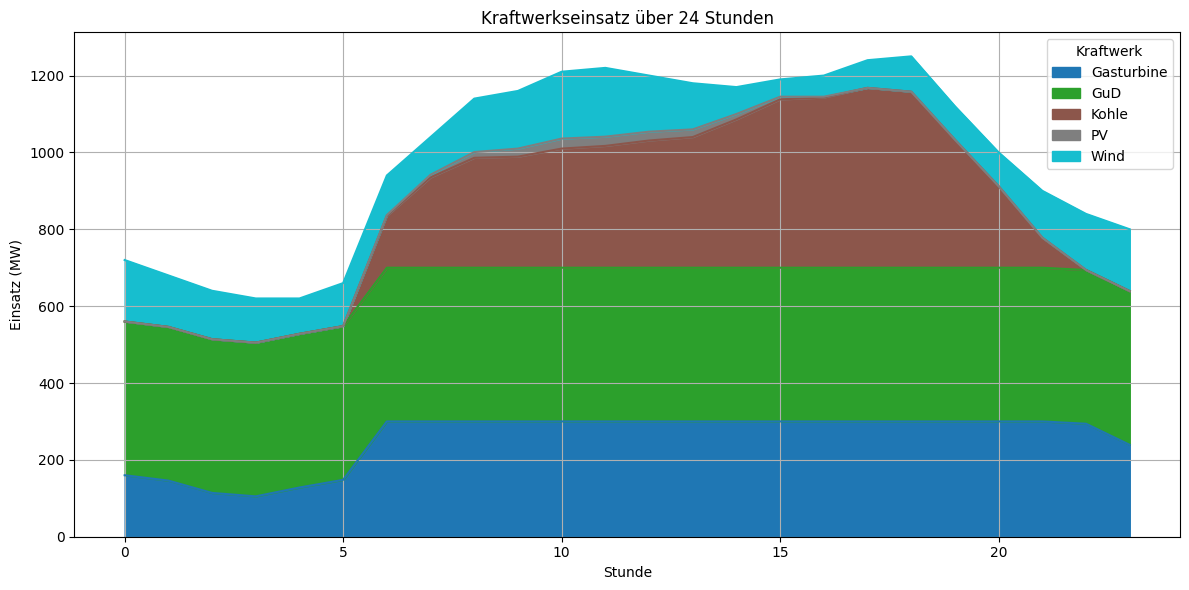

In [16]:
# Grafische Darstellung des Kraftwerkseinsatzes

df_utilization = df_res.pivot(index="Stunde", columns="Kraftwerk", values="Einsatz (MW)")

# Plot
df_utilization.plot.area(figsize=(12, 6), cmap="tab10")
plt.title("Kraftwerkseinsatz über 24 Stunden")
plt.xlabel("Stunde")
plt.ylabel("Einsatz (MW)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

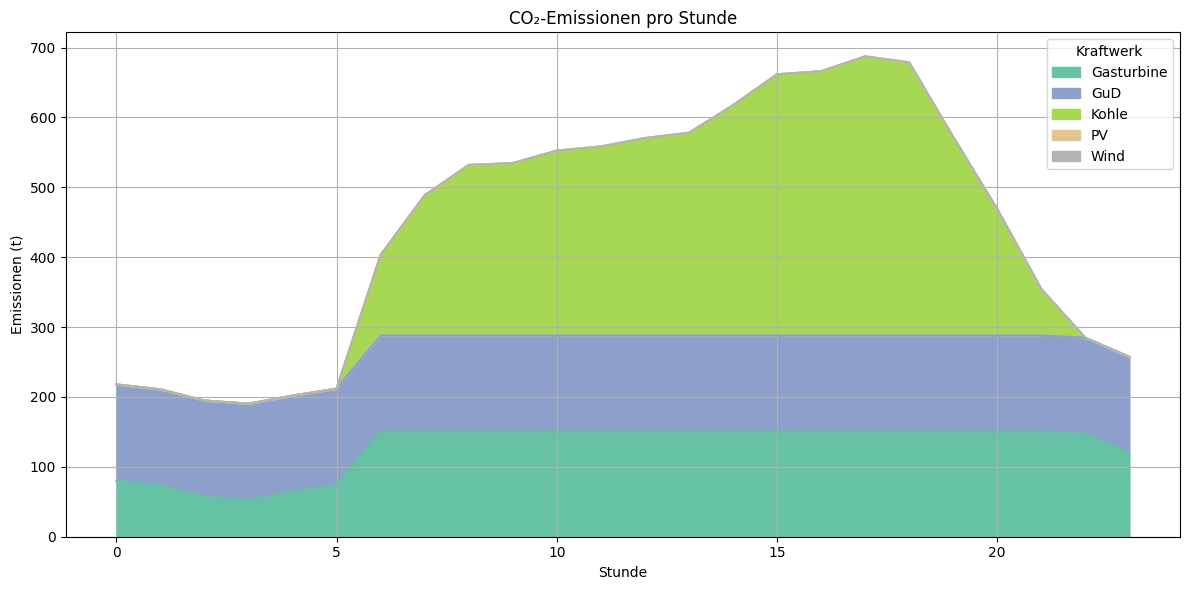

In [17]:
# Grafische Darstellung der CO2-Emissionen pro Stunde

df_emission = df_res.pivot(index="Stunde", columns="Kraftwerk", values="CO2 (t)")
df_emission.plot.area(figsize=(12, 6), cmap="Set2")
plt.title("CO₂-Emissionen pro Stunde")
plt.xlabel("Stunde")
plt.ylabel("Emissionen (t)")
plt.grid(True)
plt.legend(title="Kraftwerk")
plt.tight_layout()
plt.show()

#### c) Strompreis pro Stunde

In [18]:
df_shadow = pd.DataFrame(strompreis_liste)

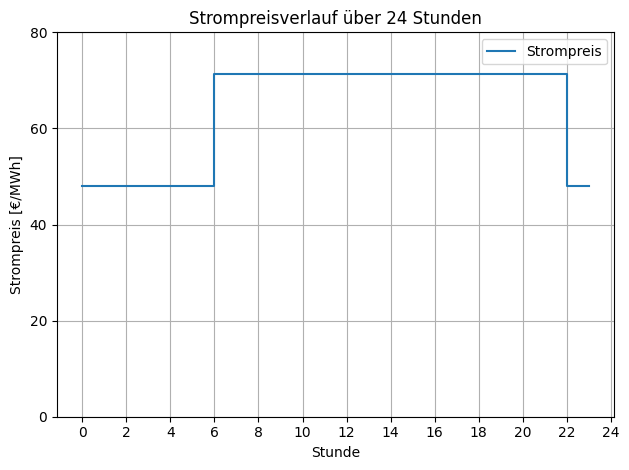

In [19]:
# Grafische Darstellung der Schattenvariable
plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

### Task 3 - Speicher

#### a) Kraftwerkseinsatzoptimierung

In [20]:
# Modell initialisieren
model = gp.Model("kraftwerkseinsatz_mit_speicher")

kraftwerksnamen = ["Wind", "PV", "GuD", "Gasturbine", "Kohle"]
n_units = 5

mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]
load = df_load["Last Winter [MW]"]
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Variablen definieren
p = {}
charge = {}
discharge = {}
soc = {}

for t in range(T):
    for i in range(n_units):
        ub = p_max[i][t] if i < 2 else p_max[i]
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

    charge[t] = model.addVar(lb=0, ub=power_pumps, name=f"charge_{t}")
    discharge[t] = model.addVar(lb=0, ub=power_pumps, name=f"discharge_{t}")
    soc[t] = model.addVar(lb=0, ub=capacity_pumps, name=f"soc_{t}")

# Speicherbilanz über die Zeit
for t in range(T):
    if t == 0:
        model.addConstr(soc[t] == eta_pump * charge[t] - discharge[t] / eta_turbine)
    else:
        model.addConstr(soc[t] == soc[t-1] + eta_pump * charge[t] - discharge[t] / eta_turbine)

# Lastdeckung (mit Speicher)
for t in range(T):
    model.addConstr(
        gp.quicksum(p[i, t] for i in range(n_units)) + discharge[t] == load[t] + charge[t],
        name=f"load_{t}"
    )

# Zielfunktion: Minimale Kosten inkl. optionaler Speicherbetriebskosten
storage_cost = 1  # optional
model.setObjective(
    gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)) +
    gp.quicksum(storage_cost * (charge[t] + discharge[t]) for t in range(T)),
    GRB.MINIMIZE
)

# Optimierung starten
model.optimize()

# Ergebnisse speichern
strompreis_liste = []

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            print(f"  {kraftwerksnamen[i]}: {p[i, t].X:.2f} MW")
        print(f"  Speicherladung: {charge[t].X:.2f} MW")
        print(f"  Speicherentladung: {discharge[t].X:.2f} MW")
        print(f"  Speicherfüllstand: {soc[t].X:.2f} MWh")

        # Strompreis (Schattenpreis)
        strompreis = model.getConstrByName(f"load_{t}").Pi
        print(f"  Strompreis: {strompreis:.2f} €/MWh")
        strompreis_liste.append({"Stunde": t, "Strompreis [€/MWh]": strompreis})


Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 48 rows, 192 columns and 263 nonzeros
Model fingerprint: 0x345b6fe1
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [1e+00, 7e+01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 10 rows and 90 columns
Presolve time: 0.01s
Presolved: 38 rows, 102 columns, 153 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    5.8816468e+05   9.907236e+02   0.000000e+00      0s
      41    9.6830318e+05   0.000000e+00   0.000000e+00      0s

Solved in 41 iterations and 0.01 seconds (0.00 work units)
Optimal objective  9.683031774e+05
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 0.00 MW
  Speicherla

In [21]:
einsatz_daten = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X
        kosten = mc[i][t] * leistung
        einsatz_daten.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten
        })

    # Speicher (optional mit Speicherbetriebskosten, z. B. 1 €/MWh)
    speicher_kosten = 1.0

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Entladung)",
        "Einsatz (MW)": discharge[t].X,
        "Kosten (€)": speicher_kosten * discharge[t].X
    })

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Ladung)",
        "Einsatz (MW)": -charge[t].X,  # negativ als Ladebedarf
        "Kosten (€)": speicher_kosten * charge[t].X
    })

df_utilization = pd.DataFrame(einsatz_daten)


In [22]:
strompreis_daten = []

for t in range(T):
    strompreis = model.getConstrByName(f"load_{t}").Pi
    strompreis_daten.append({
        "Stunde": t,
        "Strompreis [€/MWh]": strompreis
    })

df_shadow = pd.DataFrame(strompreis_daten)

In [23]:
emissions_daten = []

for t in range(T):
    for i in range(n_units):
        if co2_faktoren[i] > 0:
            emissions_daten.append({
                "Stunde": t,
                "Kraftwerk": kraftwerksnamen[i],
                "CO2 (t)": co2_faktoren[i] * p[i, t].X
            })

df_emissions = pd.DataFrame(emissions_daten)

In [24]:
print("Gesamtkosten:", round(df_utilization["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_emissions["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 968303.18 €
Gesamtemissionen: 10568.36 Tonnen CO2


#### b) Mathematische Modellierung

#### c) Auswirkung auf Emissionen

#### d) Strompreis pro Stunde

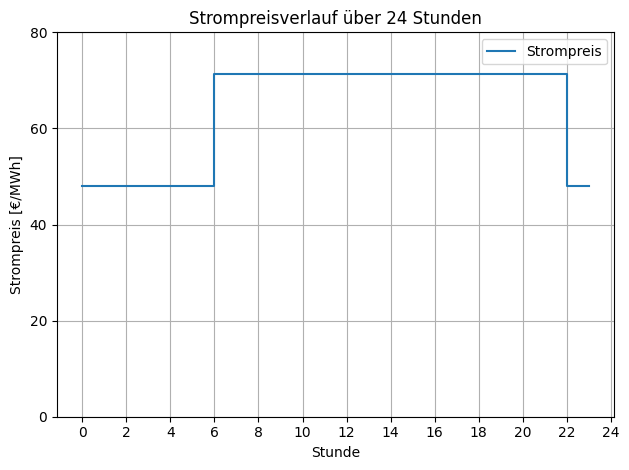

In [25]:
# Grafische Darstellung der Schattenvariable
plt.step(df_shadow["Stunde"], df_shadow["Strompreis [€/MWh]"], where="post", label="Strompreis")
plt.xlabel("Stunde")
plt.ylabel("Strompreis [€/MWh]")
plt.title("Strompreisverlauf über 24 Stunden")
plt.grid(True)
plt.xticks(range(0, 25,2))  # Stunden von 0 bis 24
plt.yticks(range(0, 100, 20))
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Speicher kann nicht preissetzend sein -> Daher: Preiskurve bleibt gleich, Arbitragebetrieb des Speichers.

#### e) Vergleich mit Task 1 und Task2

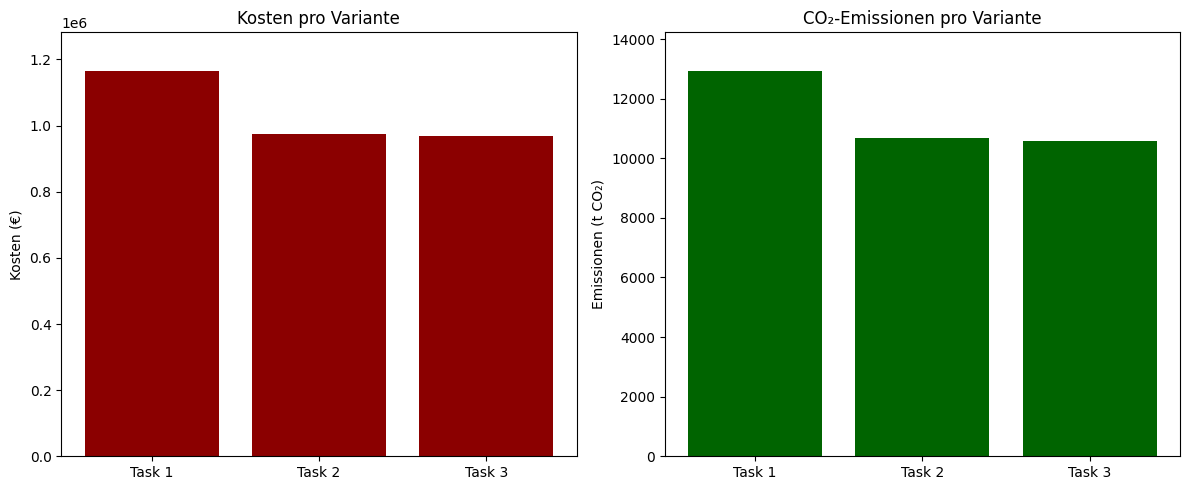

In [27]:
# Daten
tasks = ["Task 1", "Task 2", "Task 3"]
kosten = [1165522, 973597.08, 968303]
emissionen = [12933.76, 10696, 10568.36]

# Erstellen der Subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 Zeile, 2 Spalten

# Plot 1: Kosten
axs[0].bar(tasks, kosten, color="darkred")
axs[0].set_title("Kosten pro Variante")
axs[0].set_ylabel("Kosten (€)")
axs[0].set_ylim(0, max(kosten) * 1.1)

# Plot 2: Emissionen
axs[1].bar(tasks, emissionen, color="darkgreen")
axs[1].set_title("CO₂-Emissionen pro Variante")
axs[1].set_ylabel("Emissionen (t CO₂)")
axs[1].set_ylim(0, max(emissionen) * 1.1)

# Layout anpassen
plt.tight_layout()
plt.show()

### Task 4 - Kosten vs Emissionen

#### a) Minimierung der CO2-Emissionen statt den Kosten

In [28]:
# ohne Speicher - Task 2
# Minimierung der Kosten für den Kraftwerkseinsatz

strompreis_liste = []

kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
n_units = 5  # Anzahl Kraftwerke
load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]
mc = [[mc_Wind]*T,[mc_PV]*T, [mc_gud] * T,[mc_gas] * T,[mc_coal] * T] # Grenzkosten

# Maximale Leistung pro Einheit (z.B. 100 MW)
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Modell erstellen
model = gp.Model("kraftwerkseinsatz")

# Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
p = {}
for i in range(n_units):
    for t in range(T):
        # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
        if i == 0:
            ub = power_wind[t]  # Wind
        elif i == 1:
            ub = power_PV[t]    # PV
        else:
            ub = p_max[i]       # Konstante für konventionelle Kraftwerke
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

# Nachfragebedingung (Lastdeckung)
for t in range(T):
    model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

# Zielfunktion: Gesamtkosten minimieren
model.setObjective(
    gp.quicksum(co2_faktoren[i] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)

# Optimieren
model.optimize()

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            name = kraftwerksnamen[i]
            print(f"  {name}: {p[i, t].X:.2f} MW")

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0x37cbb946
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-01, 9e-01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 16 rows and 88 columns
Presolve time: 0.01s
Presolved: 8 rows, 32 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    8.9255551e+03   5.667500e+02   0.000000e+00      0s
       8    1.0696003e+04   0.000000e+00   0.000000e+00      0s

Solved in 8 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.069600336e+04
Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 160.00 MW
  Kohle: 0.00 MW
Stunde 1:
  Wind

In [29]:
ergebnisse = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X
        emission = co2_faktoren[i] * leistung
        kosten = mc[i][t] * leistung
        ergebnisse.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten,
            "CO2 (t)": emission
        })
df_res = pd.DataFrame(ergebnisse)


In [30]:
print("Gesamtkosten:", round(df_res["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_res["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 973597.09 €
Gesamtemissionen: 10696.0 Tonnen CO2


In [31]:
# Modell 3 - Speicher
# Modell initialisieren
model = gp.Model("kraftwerkseinsatz_mit_speicher")

kraftwerksnamen = ["Wind", "PV", "GuD", "Gasturbine", "Kohle"]
n_units = 5

mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]
load = df_load["Last Winter [MW]"]
p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]

# Variablen definieren
p = {}
charge = {}
discharge = {}
soc = {}

for t in range(T):
    for i in range(n_units):
        ub = p_max[i][t] if i < 2 else p_max[i]
        p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

    charge[t] = model.addVar(lb=0, ub=power_pumps, name=f"charge_{t}")
    discharge[t] = model.addVar(lb=0, ub=power_pumps, name=f"discharge_{t}")
    soc[t] = model.addVar(lb=0, ub=capacity_pumps, name=f"soc_{t}")

# Speicherbilanz über die Zeit
for t in range(T):
    if t == 0:
        model.addConstr(soc[t] == eta_pump * charge[t] - discharge[t] / eta_turbine)
    else:
        model.addConstr(soc[t] == soc[t-1] + eta_pump * charge[t] - discharge[t] / eta_turbine)

# Lastdeckung (mit Speicher)
for t in range(T):
    model.addConstr(
        gp.quicksum(p[i, t] for i in range(n_units)) + discharge[t] == load[t] + charge[t],
        name=f"load_{t}"
    )

# Zielfunktion: Minimale Kosten inkl. optionaler Speicherbetriebskosten
storage_cost = 1  # optional
model.setObjective(
    gp.quicksum(co2_faktoren[i] * p[i, t] for i in range(n_units) for t in range(T)),
    GRB.MINIMIZE
)
# Optimierung starten
model.optimize()

# Ergebnisse speichern
strompreis_liste = []

if model.status == GRB.OPTIMAL:
    for t in range(T):
        print(f"Stunde {t}:")
        for i in range(n_units):
            print(f"  {kraftwerksnamen[i]}: {p[i, t].X:.2f} MW")
        print(f"  Speicherladung: {charge[t].X:.2f} MW")
        print(f"  Speicherentladung: {discharge[t].X:.2f} MW")
        print(f"  Speicherfüllstand: {soc[t].X:.2f} MWh")


Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 48 rows, 192 columns and 263 nonzeros
Model fingerprint: 0xa225c1c8
Coefficient statistics:
  Matrix range     [9e-01, 1e+00]
  Objective range  [3e-01, 9e-01]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 10 rows and 90 columns
Presolve time: 0.01s
Presolved: 38 rows, 102 columns, 153 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.3284809e+03   2.269895e+03   0.000000e+00      0s
      22    1.0568361e+04   0.000000e+00   0.000000e+00      0s

Solved in 22 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.056836109e+04


Stunde 0:
  Wind: 160.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 0.00 MW
  Speicherladung: 140.00 MW
  Speicherentladung: 0.00 MW
  Speicherfüllstand: 126.00 MWh
Stunde 1:
  Wind: 134.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 0.00 MW
  Speicherladung: 154.00 MW
  Speicherentladung: 0.00 MW
  Speicherfüllstand: 264.60 MWh
Stunde 2:
  Wind: 126.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 114.00 MW
  Kohle: 0.00 MW
  Speicherladung: 0.00 MW
  Speicherentladung: 0.00 MW
  Speicherfüllstand: 264.60 MWh
Stunde 3:
  Wind: 115.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 153.67 MW
  Kohle: 0.00 MW
  Speicherladung: 48.67 MW
  Speicherentladung: 0.00 MW
  Speicherfüllstand: 308.40 MWh
Stunde 4:
  Wind: 92.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW
  Gasturbine: 300.00 MW
  Kohle: 0.00 MW
  Speicherladung: 172.00 MW
  Speicherentladung: 0.00 MW
  Speicherfüllstand: 463.20 MWh
Stunde 5:
  Wind: 112.00 MW
  PV: 0.00 MW
  GuD: 400.00 MW


In [32]:
einsatz_daten = []

for t in range(T):
    for i in range(n_units):
        leistung = p[i, t].X
        kosten = mc[i][t] * leistung
        einsatz_daten.append({
            "Stunde": t,
            "Kraftwerk": kraftwerksnamen[i],
            "Einsatz (MW)": leistung,
            "Kosten (€)": kosten
        })

    # Speicher (optional mit Speicherbetriebskosten, z. B. 1 €/MWh)
    speicher_kosten = 1.0

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Entladung)",
        "Einsatz (MW)": discharge[t].X,
        "Kosten (€)": speicher_kosten * discharge[t].X
    })

    einsatz_daten.append({
        "Stunde": t,
        "Kraftwerk": "Speicher (Ladung)",
        "Einsatz (MW)": -charge[t].X,  # negativ als Ladebedarf
        "Kosten (€)": speicher_kosten * charge[t].X
    })

df_utilization = pd.DataFrame(einsatz_daten)


In [33]:
emissions_daten = []

for t in range(T):
    for i in range(n_units):
        if co2_faktoren[i] > 0:
            emissions_daten.append({
                "Stunde": t,
                "Kraftwerk": kraftwerksnamen[i],
                "CO2 (t)": co2_faktoren[i] * p[i, t].X
            })

df_emissions = pd.DataFrame(emissions_daten)

In [34]:
print("Gesamtkosten:", round(df_utilization["Kosten (€)"].sum(),2), "€")
print("Gesamtemissionen:", round(df_emissions["CO2 (t)"].sum(),2), "Tonnen CO2")

Gesamtkosten: 968303.18 €
Gesamtemissionen: 10568.36 Tonnen CO2


#### b) Grafische Darstellung der Ergebnisse

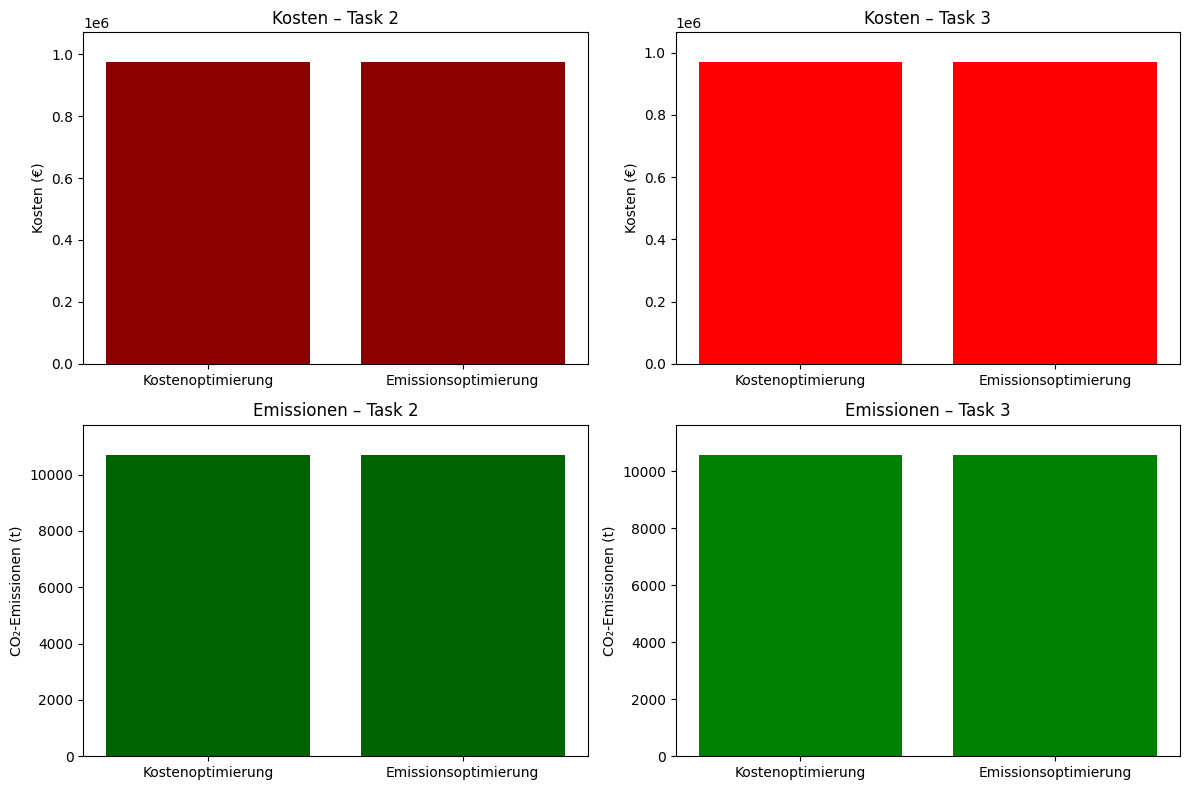

In [35]:
# Daten
tasks = ["Kostenoptimierung", "Emissionsoptimierung"]
kosten2 = [973597.08, 973597.08]
kosten3 = [968303, 968303]
emissionen2 = [10696, 10696]
emissionen3 = [10568.36, 10568.36]

# Erstellen der Subplots (2 Zeilen, 2 Spalten)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Kosten Task 2
axs[0, 0].bar(tasks, kosten2, color="darkred")
axs[0, 0].set_title("Kosten – Task 2")
axs[0, 0].set_ylabel("Kosten (€)")
axs[0, 0].set_ylim(0, max(kosten2) * 1.1)

# Plot 2: Emissionen Task 2
axs[1, 0].bar(tasks, emissionen2, color="darkgreen")
axs[1, 0].set_title("Emissionen – Task 2")
axs[1, 0].set_ylabel("CO₂-Emissionen (t)")
axs[1, 0].set_ylim(0, max(emissionen2) * 1.1)

# Plot 3: Kosten Task 3
axs[0, 1].bar(tasks, kosten3, color="red")
axs[0, 1].set_title("Kosten – Task 3")
axs[0, 1].set_ylabel("Kosten (€)")
axs[0, 1].set_ylim(0, max(kosten3) * 1.1)

# Plot 4: Emissionen Task 3
axs[1, 1].bar(tasks, emissionen3, color="green")
axs[1, 1].set_title("Emissionen – Task 3")
axs[1, 1].set_ylabel("CO₂-Emissionen (t)")
axs[1, 1].set_ylim(0, max(emissionen3) * 1.1)

# Layout anpassen
plt.tight_layout()
plt.show()

In [36]:
# Werte für Gesamtkosten und -emissionen sind egal ob Kostenoptimierung oder Emissionsoptimierung genau gleich,
# da bereits bei der Kostenoptimierung die Technologien mit den geringsten CO2-Emissionen zuerst verwendet werden.

#### c) Sensitivitätsanalyse CO2-Preis 

In [47]:
co2_prices = [0,20,40,60,80]  # €/t CO2
results = []

for CO2_price in co2_prices:
    print(f"\n--- Optimierung für CO2-Preis: {CO2_price} €/t ---")

    # Grenzkosten neu berechnen
    mc_coal = fuelcost_coal / (eta_coal * H_coal) + (CO2_price * CO2_coal)
    mc_gud  = fuelcost_gas / (eta_gud * H_ngas) + (CO2_price * CO2_gud)
    mc_gas  = fuelcost_gas / (eta_gas * H_ngas) + (CO2_price * CO2_gas)
    mc_PV = 0
    mc_Wind = 0

    kraftwerksnamen = ["Wind","PV","GuD", "Gasturbine", "Kohle"]
    n_units = 5  # Anzahl Kraftwerke
    load = df_load['Last Winter [MW]']  # Beispiel-Lastkurve
    co2_faktoren = [0,0,CO2_gud, CO2_gas, CO2_coal]


    # Maximale Leistung pro Einheit (z.B. 100 MW)
    p_max = [power_wind, power_PV, power_gud, power_gas, power_coal]
    mc = [[mc_Wind]*T, [mc_PV]*T, [mc_gud]*T, [mc_gas]*T, [mc_coal]*T]

    # Neues Modell erzeugen
    model = gp.Model(f"Kraftwerk_CO2_{CO2_price}")
    # Entscheidungsvariablen: p[i][t] = Leistung Einheit i in Stunde t
    p = {}
    for i in range(n_units):
        for t in range(T):
            # Zeitabhängige Obergrenzen für Wind (i==0) und PV (i==1)
            if i == 0:
                ub = power_wind[t]  # Wind
            elif i == 1:
                ub = power_PV[t]    # PV
            else:
                ub = p_max[i]       # Konstante für konventionelle Kraftwerke
            p[i, t] = model.addVar(lb=0, ub=ub, name=f"p_{i}_{t}")

    # Lastdeckung
    for t in range(T):
        model.addConstr(gp.quicksum(p[i, t] for i in range(n_units)) == load[t], name=f"load_{t}")

    # Zielfunktion: Kosten minimieren
    model.setObjective(
        gp.quicksum(mc[i][t] * p[i, t] for i in range(n_units) for t in range(T)),
        GRB.MINIMIZE
    )

    model.optimize()

    if model.status == GRB.OPTIMAL:
        total_cost = 0
        total_emissions = 0
        for t in range(T):
            for i in range(n_units):
                p_it = p[i, t].X
                total_cost += mc[i][t] * p_it
                total_emissions += co2_faktoren[i] * p_it
        print(f"Gesamtkosten: {total_cost:.2f} €")
        print(f"CO₂-Emissionen: {total_emissions:.2f} t")

        results.append({
            "CO2-Preis": CO2_price,
            "Kosten (€)": total_cost,
            "Emissionen (t CO2)": total_emissions
        })


--- Optimierung für CO2-Preis: 0 €/t ---
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (26100.2))

CPU model: 12th Gen Intel(R) Core(TM) i5-1235U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 24 rows, 120 columns and 120 nonzeros
Model fingerprint: 0x3e1ed7e8
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+00, 8e+00]
  Bounds range     [2e+00, 6e+02]
  RHS range        [6e+02, 1e+03]
Presolve removed 14 rows and 82 columns
Presolve time: 0.01s
Presolved: 10 rows, 38 columns, 38 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    6.7196897e+04   6.183750e+02   0.000000e+00      0s
      10    8.2381296e+04   0.000000e+00   0.000000e+00      0s

Solved in 10 iterations and 0.02 seconds (0.00 work units)
Optimal objective  8.238129581e+04
Gesamtkosten: 82381.30 €
CO₂-Emissionen: 14422.00 t

--- Optimierung für

In [ ]:
df_results = pd.DataFrame(results)

   CO2-Preis     Kosten (€)  Emissionen (t CO2)
0          0   82381.295807        14422.004205
1         20  331836.889643        10696.003364
2         40  545756.956927        10696.003364
3         60  759677.024210        10696.003364
4         80  973597.091493        10696.003364


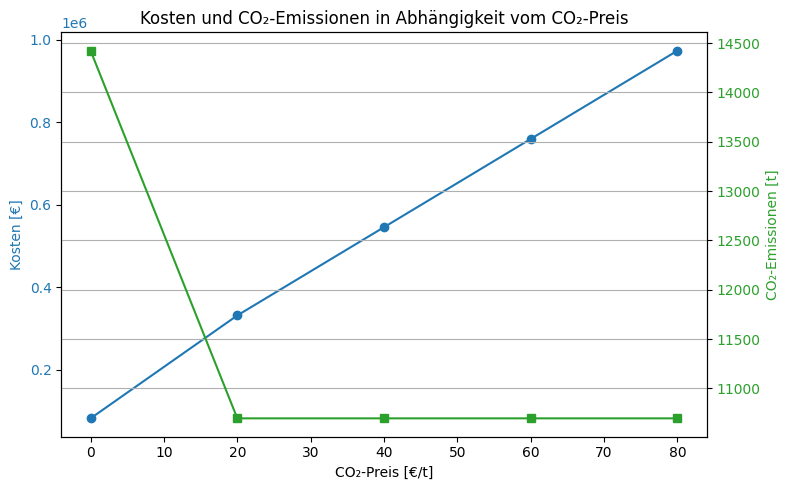

In [53]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Erste Achse: Kosten
color = 'tab:blue'
ax1.set_xlabel('CO₂-Preis [€/t]')
ax1.set_ylabel('Kosten [€]', color=color)
ax1.plot(df_results["CO2-Preis"], df_results["Kosten (€)"], marker='o', color=color, label='Kosten')
ax1.tick_params(axis='y', labelcolor=color)

# Zweite Achse: Emissionen
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('CO₂-Emissionen [t]', color=color)
ax2.plot(df_results["CO2-Preis"], df_results["Emissionen (t CO2)"], marker='s', color=color, label='Emissionen')
ax2.tick_params(axis='y', labelcolor=color)

# Titel und Layout
plt.title("Kosten und CO₂-Emissionen in Abhängigkeit vom CO₂-Preis")
fig.tight_layout()
plt.grid(True)
plt.show()